#Solar Power Generation based on Regression

Step 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('default')

Step 2: Load the Dataset

In [2]:
df = pd.read_csv("solarpowergeneration.csv")

Step 3: Basic Data Inspection

In [3]:
# First 5 rows
df.head()

,distance-to-solar-noon,temperature,wind-direction,wind-speed,sky-cover,visibility,humidity,average-wind-speed-(period),average-pressure-(period),power-generated
0,0.859897,69,28,7.5,0,10.0,75,8.0,29.82,0
1,0.628535,69,28,7.5,0,10.0,77,5.0,29.85,0
2,0.397172,69,28,7.5,0,10.0,70,0.0,29.89,5418
3,0.165810,69,28,7.5,0,10.0,33,0.0,29.91,25477
4,0.065553,69,28,7.5,0,10.0,21,3.0,29.89,30069


In [4]:
# Shape of dataset
df.shape

(2920, 10)

In [5]:
# Column names
df.columns

Index(['distance-to-solar-noon', 'temperature', 'wind-direction', 'wind-speed',
       'sky-cover', 'visibility', 'humidity', 'average-wind-speed-(period)',
       'average-pressure-(period)', 'power-generated'],
      dtype='object')

In [6]:
# Data types and null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2920 entries, 0 to 2919
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   distance-to-solar-noon       2920 non-null   float64
 1   temperature                  2920 non-null   int64  
 2   wind-direction               2920 non-null   int64  
 3   wind-speed                   2920 non-null   float64
 4   sky-cover                    2920 non-null   int64  
 5   visibility                   2920 non-null   float64
 6   humidity                     2920 non-null   int64  
 7   average-wind-speed-(period)  2919 non-null   float64
 8   average-pressure-(period)    2920 non-null   float64
 9   power-generated              2920 non-null   int64  
dtypes: float64(5), int64(5)
memory usage: 228.3 KB


Step 4: Statistical Summary

In [7]:
df.describe()

,distance-to-solar-noon,temperature,wind-direction,wind-speed,sky-cover,visibility,humidity,average-wind-speed-(period),average-pressure-(period),power-generated
count,2920.000000,2920.000000,2920.000000,2920.000000,2920.000000,2920.000000,2920.000000,2919.000000,2920.000000,2920.000000
mean,0.503294,58.468493,24.953425,10.096986,1.987671,9.557705,73.513699,10.129154,30.017760,6979.846233
std,0.298024,6.841200,6.915178,4.838185,1.411978,1.383884,15.077139,7.261547,0.142006,10312.336413
min,0.050401,42.000000,1.000000,1.100000,0.000000,0.000000,14.000000,0.000000,29.480000,0.000000
25%,0.243714,53.000000,25.000000,6.600000,1.000000,10.000000,65.000000,5.000000,29.920000,0.000000
50%,0.478957,59.000000,27.000000,10.000000,2.000000,10.000000,77.000000,9.000000,30.000000,404.000000
75%,0.739528,63.000000,29.000000,13.100000,3.000000,10.000000,84.000000,15.000000,30.110000,12723.500000
max,1.141361,78.000000,36.000000,26.600000,4.000000,10.000000,100.000000,40.000000,30.530000,36580.000000


Step 5: Check Missing Values

In [8]:
df.isnull().sum()

,0
distance-to-solar-noon,0
temperature,0
wind-direction,0
wind-speed,0
sky-cover,0
visibility,0
humidity,0
average-wind-speed-(period),1
average-pressure-(period),0
power-generated,0


In [9]:
# missing values exist:
df = df.dropna()   # or use fillna() based on requirement
df

,distance-to-solar-noon,temperature,wind-direction,wind-speed,sky-cover,visibility,humidity,average-wind-speed-(period),average-pressure-(period),power-generated
0,0.859897,69,28,7.5,0,10.0,75,8.0,29.82,0
1,0.628535,69,28,7.5,0,10.0,77,5.0,29.85,0
2,0.397172,69,28,7.5,0,10.0,70,0.0,29.89,5418
3,0.165810,69,28,7.5,0,10.0,33,0.0,29.91,25477
4,0.065553,69,28,7.5,0,10.0,21,3.0,29.89,30069
...,...,...,...,...,...,...,...,...,...,...
2915,0.166453,63,27,13.9,4,10.0,75,10.0,29.93,6995
2916,0.064020,63,27,13.9,1,10.0,66,15.0,29.91,29490
2917,0.294494,63,27,13.9,2,10.0,68,21.0,29.88,17257
2918,0.524968,63,27,13.9,2,10.0,81,17.0,29.87,677


Step 6: Check Duplicates

In [10]:
df.duplicated().sum()

# Remove duplicates if any
df = df.drop_duplicates()

Step 7: Target Variable Analysis

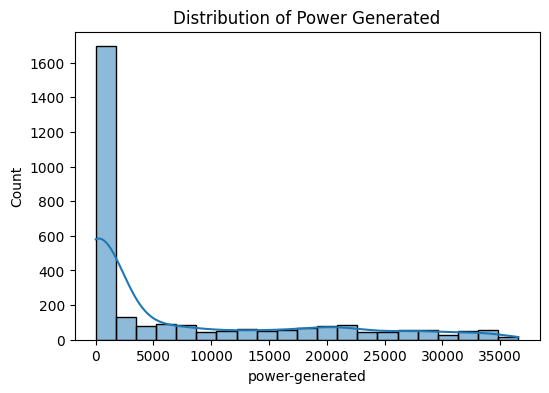

In [11]:
plt.figure(figsize=(6,4))
sns.histplot(df['power-generated'], kde=True)
plt.title("Distribution of Power Generated")
plt.show()

Step 8: Feature Distribution (Univariate Analysis)

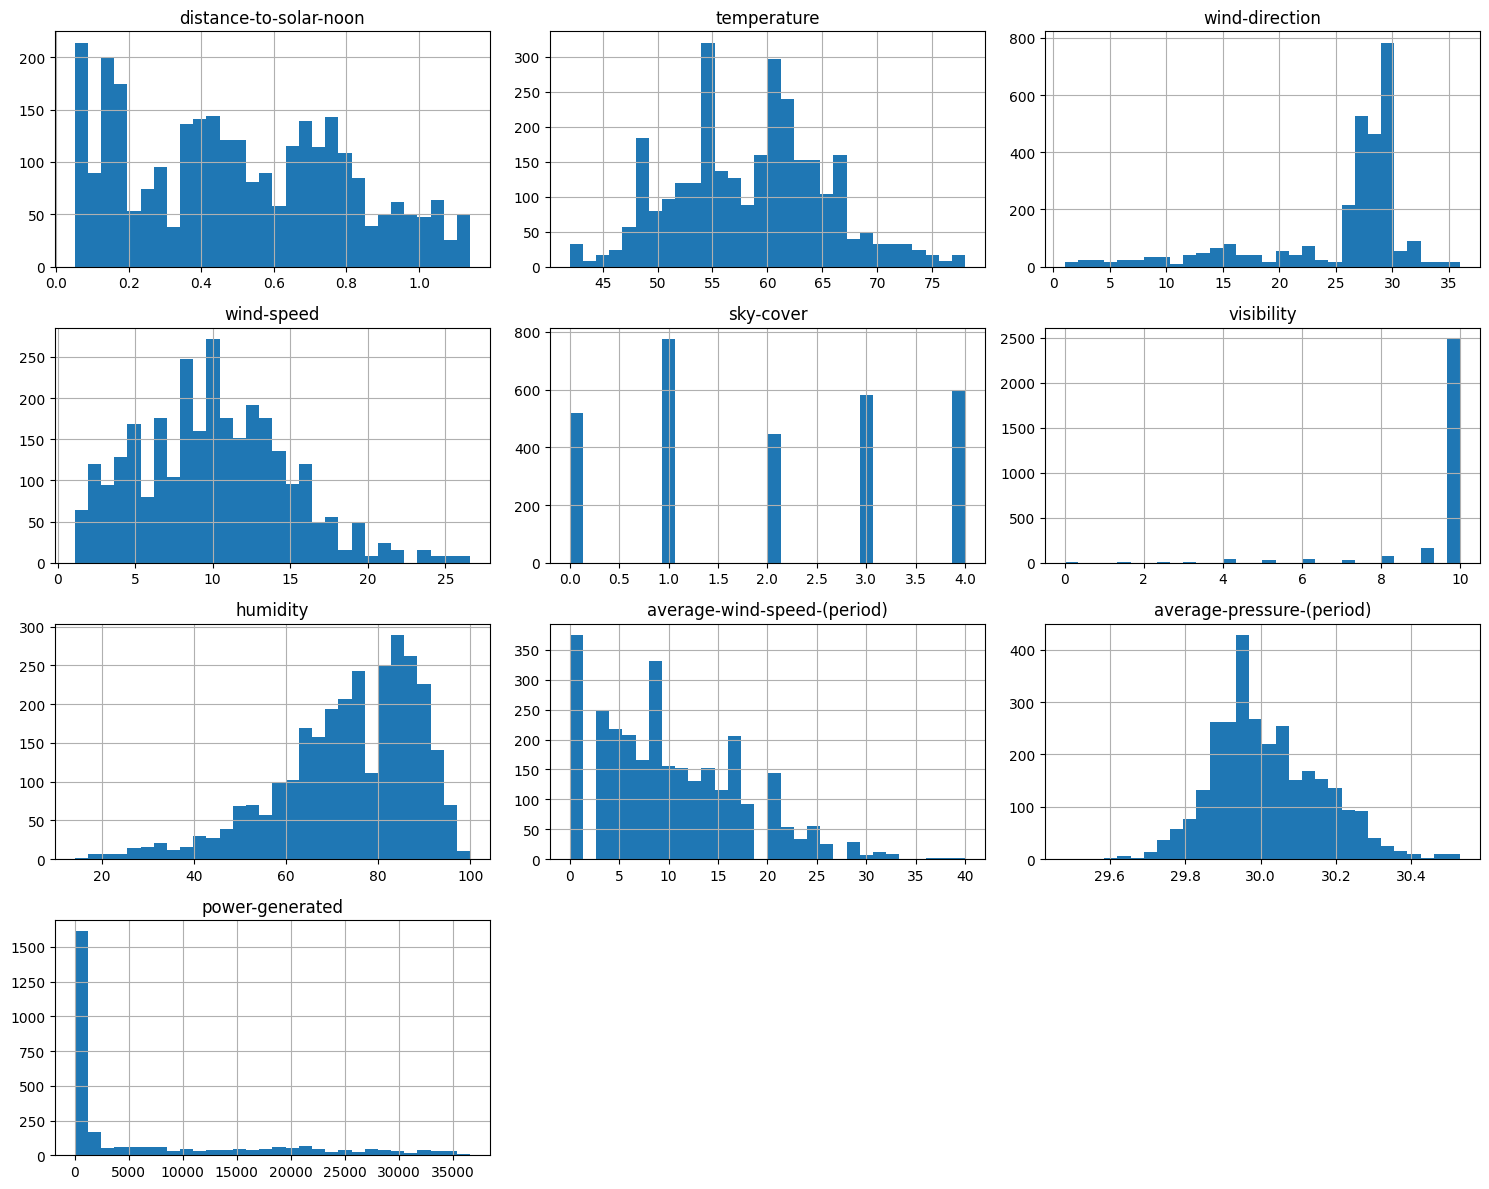

In [12]:
df.hist(figsize=(15,12), bins=30)
plt.tight_layout()
plt.show()

Step 9: Correlation Analysis

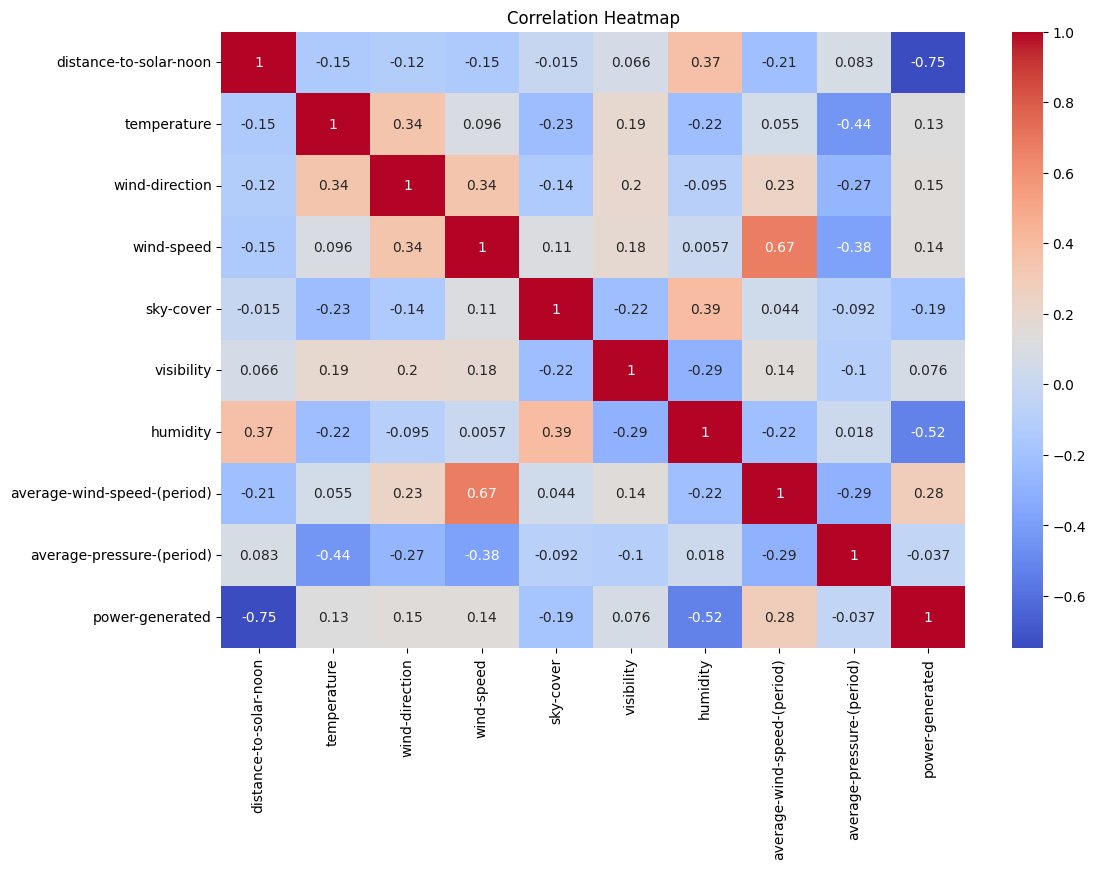

In [13]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Step 10: Relationship with Target (Bivariate Analysis)

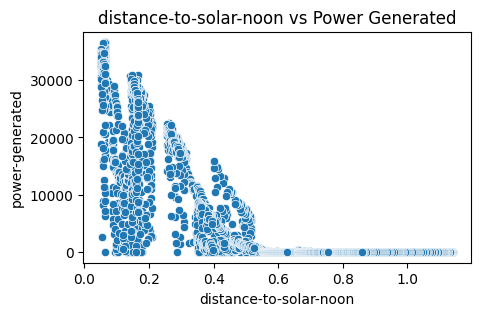

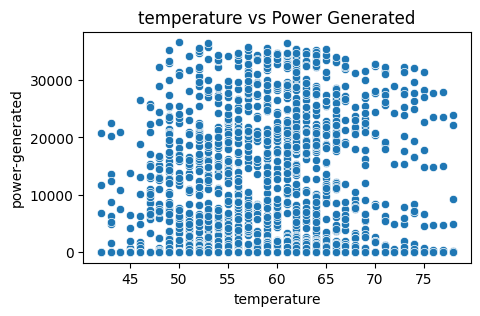

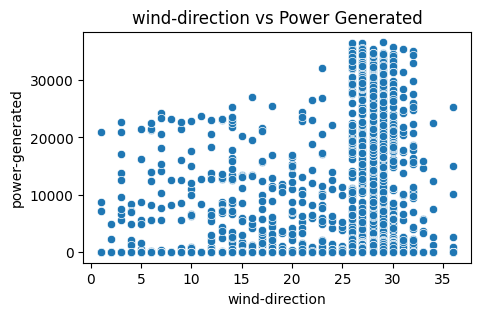

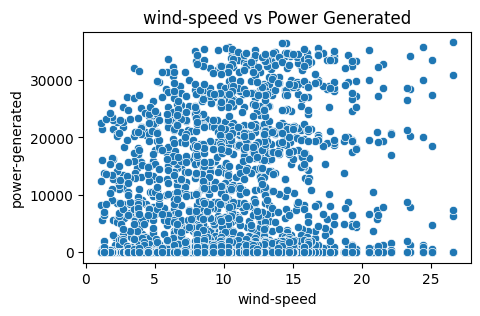

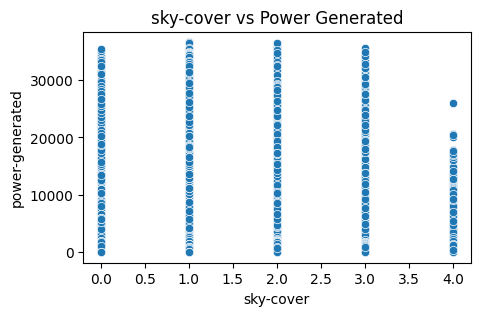

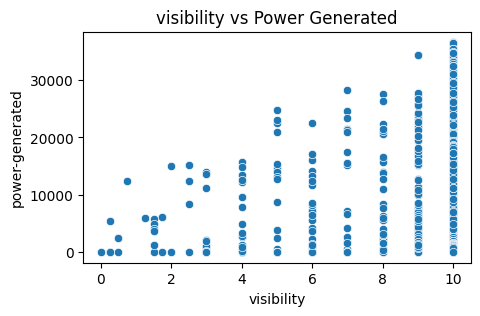

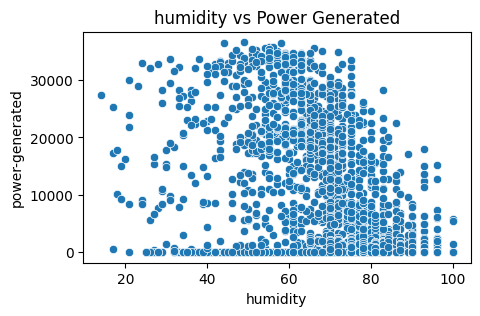

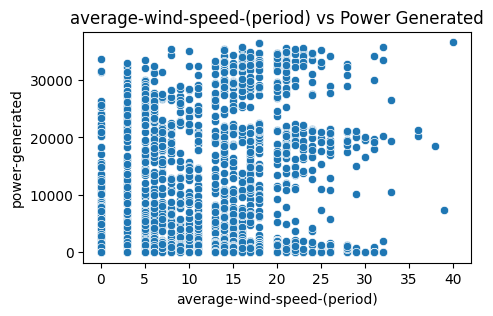

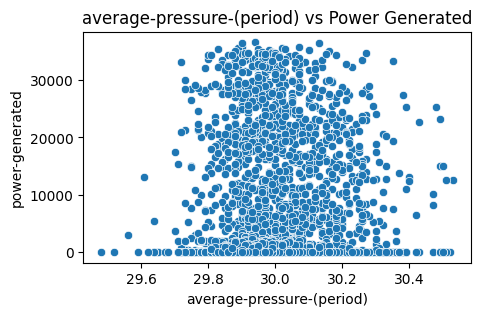

In [14]:
features = df.columns.drop('power-generated')

for col in features:
    plt.figure(figsize=(5,3))
    sns.scatterplot(x=df[col], y=df['power-generated'])
    plt.title(f"{col} vs Power Generated")
    plt.show()

Step 11: Outlier Detection (Boxplots)

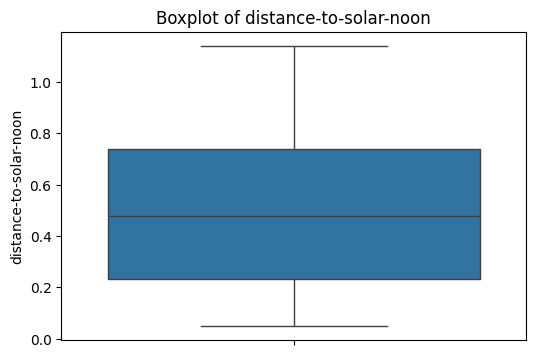

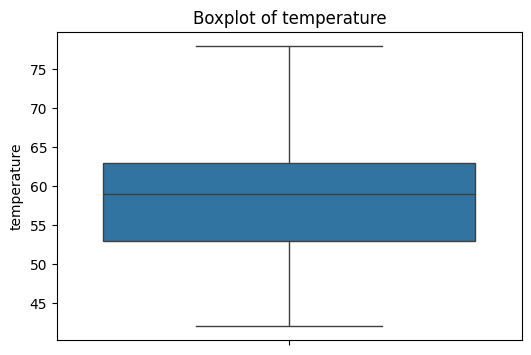

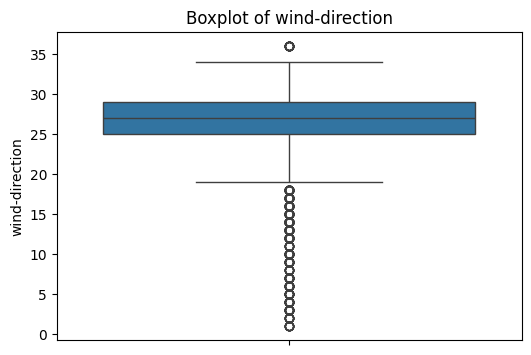

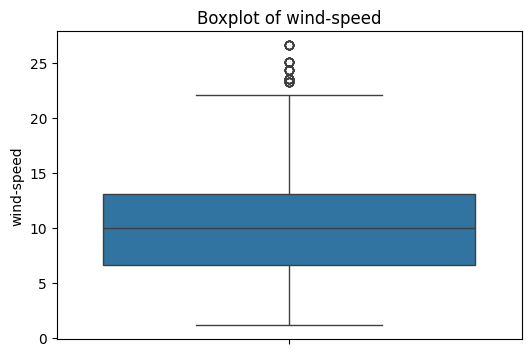

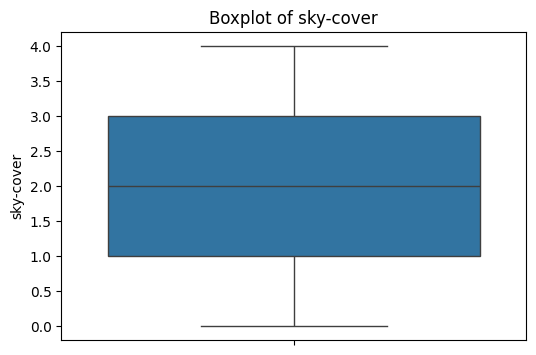

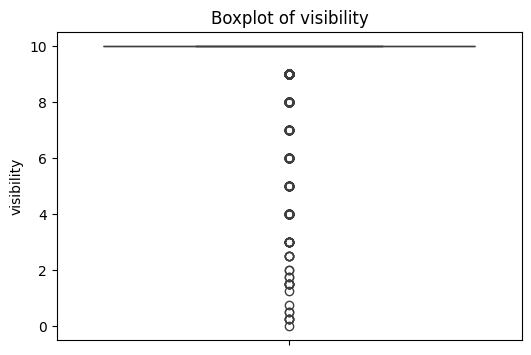

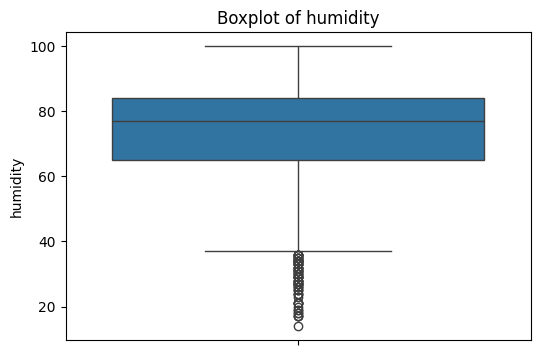

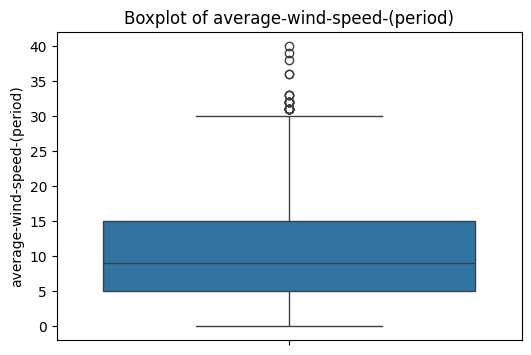

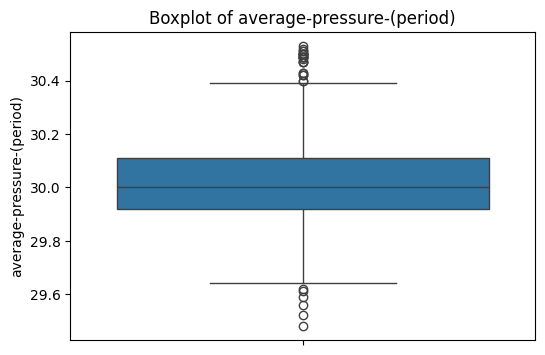

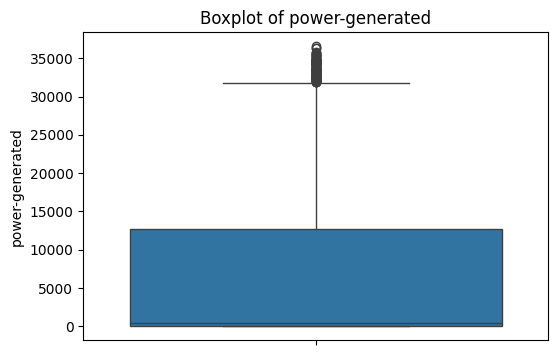

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in df.columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


**Step 12: EDA Insights (Write in Report)**

Example insights you can mention:

Power generated is strongly correlated with distance_to_solar_noon

Temperature and sky cover impact energy production

Some features contain outliers (wind speed, pressure)

Dataset is suitable for regression modeling

#Now Apply StandardScaler and OneHotEncoder

Step 1: Separate Features and Target

In [17]:
from sklearn.model_selection import train_test_split

X = df.drop('power-generated', axis=1)
y = df['power-generated']

# Train-Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Step 2: Identify Numerical and Categorical Columns

In [18]:
# Numerical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns

# Categorical columns
cat_cols = X.select_dtypes(include=['object']).columns

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerical Columns: Index(['distance-to-solar-noon', 'temperature', 'wind-direction', 'wind-speed',
       'sky-cover', 'visibility', 'humidity', 'average-wind-speed-(period)',
       'average-pressure-(period)'],
      dtype='object')
Categorical Columns: Index([], dtype='object')


Step 3: Apply StandardScaler and OneHotEncoder

In [19]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [21]:
# Create transformers
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Combine using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

Step 4: Fit and Transform Data

In [22]:
# Fit on training data
X_train_scaled = preprocessor.fit_transform(X_train)

# Transform test data
X_test_scaled = preprocessor.transform(X_test)

print("Training Data Shape:", X_train_scaled.shape)
print("Testing Data Shape:", X_test_scaled.shape)

Training Data Shape: (2335, 9)
Testing Data Shape: (584, 9)


Step 5 : Convert Back to DataFrame

In [23]:
# Get column names after encoding
encoded_cat_cols = []

if len(cat_cols) > 0:
    encoded_cat_cols = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols)

final_columns = list(num_cols) + list(encoded_cat_cols)

X_train_final = pd.DataFrame(X_train_scaled, columns=final_columns)
X_test_final = pd.DataFrame(X_test_scaled, columns=final_columns)

X_train_final.head()

,distance-to-solar-noon,temperature,wind-direction,wind-speed,sky-cover,visibility,humidity,average-wind-speed-(period),average-pressure-(period)
0,-1.151650,0.964042,0.307167,0.731274,-0.726603,0.329805,-0.389001,0.527667,-0.968589
1,0.100914,-0.644678,0.307167,3.127083,-0.021149,0.329805,0.012052,2.043000,-0.757699
2,1.072219,-1.668409,-0.695959,-0.289549,0.684306,0.329805,0.012052,-0.161120,1.070015
3,-1.505491,1.256536,0.593775,0.127113,-1.432058,0.329805,-2.862158,0.940940,-1.530963
4,-1.130085,0.671547,0.307167,0.793773,1.389760,0.329805,0.078894,-0.023363,-0.617106
